# 436 millones de años. Solo conocemos el 30% de sus rasgos. ¿Y si eso bastara para reescribir la historia de los peces?

**Paper:** Zhu et al. (2025) — *Eosteus, the oldest osteichthyan.* Nature.
[DOI: 10.1038/s41586-026-10125-2](https://doi.org/10.1038/s41586-026-10125-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-13-pez-imposible-436-millones-anos/notebook.ipynb)

**Video:** [Ver en YouTube](https://www.youtube.com/watch?v=yJAgAv2eJGk)

## El contexto

Los osteíctios (peces óseos) dominan la biodiversidad vertebrada actual — incluyen desde el salmón hasta nosotros. Pero su registro fósil antes del Devónico era escaso y fragmentario.

Un equipo encontró un pez diminuto, casi completo, en la Lagerstätte de Chongqing (China): **Eosteus**, de ~436 millones de años. Es el osteíctio articulado más antiguo jamás encontrado.

Para ubicarlo en el árbol de la vida, construyeron una **matriz filogenética**: una tabla de 163 especies × 709 caracteres morfológicos, donde cada rasgo se codifica como presente (0/1/2) o desconocido (?). Esa matriz es pública — y es lo que vamos a explorar.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EOSTEUS_COMPLETITUD = 30.5    # % de caracteres codificados
TOTAL_TAXA = 163
TOTAL_CHARS = 709
FUENTE = 'Fuente: Zhu et al. (2025), Nature | Datos: Figshare (SI1)'
COLOR_EOSTEUS = '#DC2626'     # Rojo — destaca al protagonista
COLOR_DATOS = '#2563EB'       # Azul CaM
COLOR_SECUNDARIO = '#059669'  # Emerald
COLOR_REFERENCIA = '#D97706'  # Amber
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

# ── Setup ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Cargar datos ──
df_comp = pd.read_csv('datos/completitud_taxa.csv')
df_sim = pd.read_csv('datos/similitud_eosteus.csv')

# Colores por grupo
COLORES_GRUPO = {
    'Actinopterigio': '#2563EB',
    'Sarcopterigio': '#059669',
    'Stem Osteictio': '#DC2626',
    'Condrictio': '#7C3AED',
    'Acantodio': '#D97706',
    'Placodermo': '#BBBBBB',
    'Agnato': '#F59E0B',
    'Otro': '#D1D5DB',
}

print(f"Matriz filogenética: {len(df_comp)} taxa × {TOTAL_CHARS} caracteres")
eosteus = df_comp[df_comp['taxon'] == 'Eosteus'].iloc[0]
print(f"Eosteus: {eosteus['n_coded']}/{eosteus['n_total']} caracteres codificados ({eosteus['pct_complete']}%)")
print(f"Rank: {(df_comp['pct_complete'] >= eosteus['pct_complete']).sum()}/{len(df_comp)}")

Matriz filogenética: 163 taxa × 709 caracteres
Eosteus: 216/709 caracteres codificados (30.5%)
Rank: 112/163


## ¿Cuánto sabemos de cada especie?

Veamos.

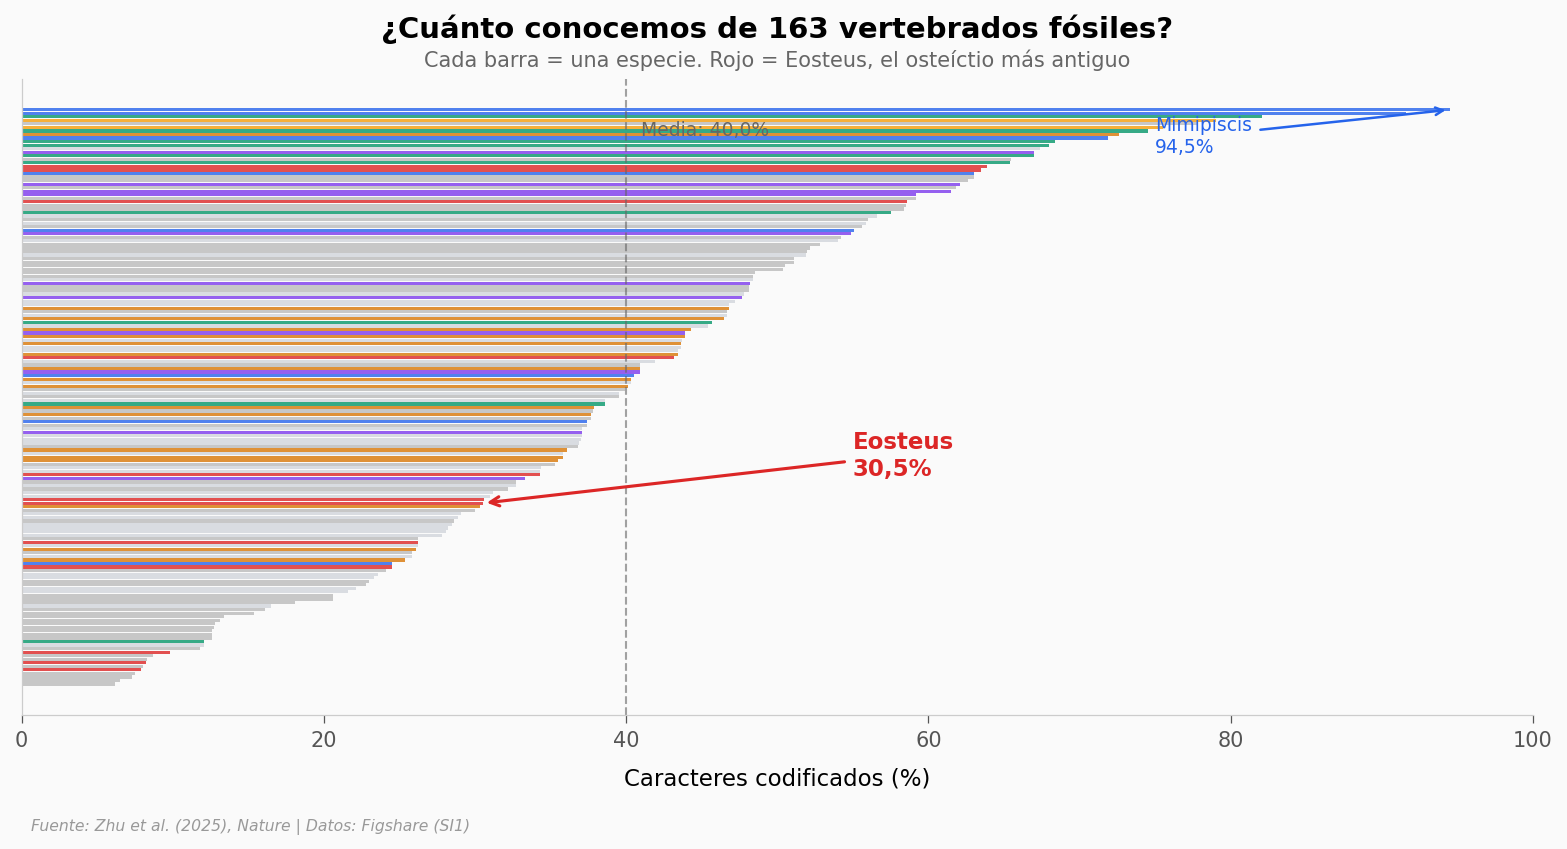

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por completitud
df_sorted = df_comp.sort_values('pct_complete', ascending=True).reset_index(drop=True)

# Colores: Eosteus en rojo, resto por grupo
colors = []
for _, row in df_sorted.iterrows():
    if row['taxon'] == 'Eosteus':
        colors.append(COLOR_EOSTEUS)
    else:
        colors.append(COLORES_GRUPO.get(row['grupo'], '#D1D5DB'))

ax.barh(range(len(df_sorted)), df_sorted['pct_complete'], color=colors, alpha=0.8, height=0.9)

# Marcar Eosteus
eosteus_idx = df_sorted[df_sorted['taxon'] == 'Eosteus'].index[0]
ax.annotate('Eosteus\n30,5%', xy=(df_sorted.iloc[eosteus_idx]['pct_complete'], eosteus_idx),
            xytext=(55, eosteus_idx + 8), fontsize=11, fontweight='bold', color=COLOR_EOSTEUS,
            arrowprops=dict(arrowstyle='->', color=COLOR_EOSTEUS, lw=1.5))

# Marcar el más completo
top_idx = df_sorted['pct_complete'].idxmax()
ax.annotate('Mimipiscis\n94,5%', xy=(df_sorted.iloc[top_idx]['pct_complete'], top_idx),
            xytext=(75, top_idx - 12), fontsize=9, color='#2563EB',
            arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.2))

# Línea de media
ax.axvline(x=40.0, color='#666666', linewidth=1, linestyle='--', alpha=0.6)
ax.text(41, len(df_sorted) * 0.95, 'Media: 40,0%', fontsize=9, color='#666666')

ax.set_xlabel('Caracteres codificados (%)', fontsize=11)
ax.set_title('¿Cuánto conocemos de 163 vertebrados fósiles?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada barra = una especie. Rojo = Eosteus, el osteíctio más antiguo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_yticks([])
ax.set_xlim(0, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/completitud_hero.png', dpi=200, bbox_inches='tight')
plt.show()

Eosteus apenas supera el 30% de caracteres codificados — normal para un fósil del Silúrico, donde la preservación es excepcional solo en contadas localidades. La media de completitud de las 163 especies es 40% (mediana 39,5%, IQR: 26–52%).

Lo llamativo: incluso con ese 30%, el análisis bayesiano logra ubicar a Eosteus en el árbol evolutivo — aunque el consenso estricto lo deja sin resolver. ¿Cómo? Porque no todos los caracteres pesan igual en un análisis filogenético — y los que sí se preservaron incluyen rasgos clave para definir parentescos.

## ¿A quién se parece Eosteus?

De los 216 caracteres que conocemos de Eosteus, podemos comparar cuántos coinciden con cada otra especie.

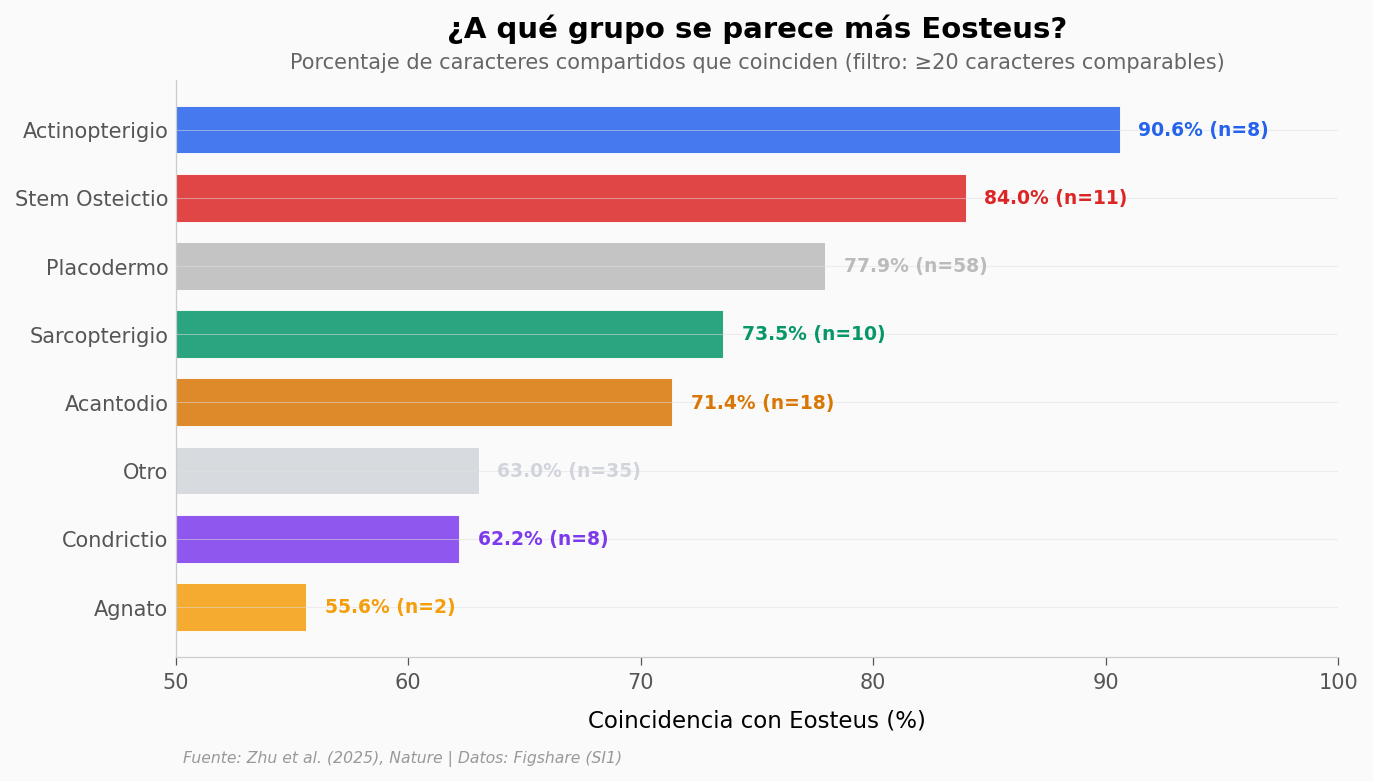

In [3]:
# Similitud media por grupo (excluyendo taxa con <20 caracteres comparables)
df_sim_filt = df_sim[df_sim['caracteres_comparables'] >= 20].copy()
group_sim = df_sim_filt.groupby('grupo').agg(
    similitud_media=('similitud_pct', 'mean'),
    n_taxa=('similitud_pct', 'count')
).sort_values('similitud_media', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

colors_bar = [COLORES_GRUPO.get(g, '#D1D5DB') for g in group_sim['grupo']]
bars = ax.barh(range(len(group_sim)), group_sim['similitud_media'],
               color=colors_bar, alpha=0.85, height=0.7, edgecolor='white', linewidth=0.5)

# Inline labels
for i, (_, row) in enumerate(group_sim.iterrows()):
    ax.text(row['similitud_media'] + 0.8, i,
            f"{row['similitud_media']:.1f}% (n={int(row['n_taxa'])})",
            va='center', fontsize=9, fontweight='bold',
            color=COLORES_GRUPO.get(row['grupo'], '#666666'))

ax.set_yticks(range(len(group_sim)))
ax.set_yticklabels(group_sim['grupo'], fontsize=10)
ax.set_xlabel('Coincidencia con Eosteus (%)', fontsize=11)
ax.set_title('¿A qué grupo se parece más Eosteus?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Porcentaje de caracteres compartidos que coinciden (filtro: ≥20 caracteres comparables)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(50, 100)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/similitud_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

Los actinopterigios (peces con aletas de radios — desde el pez payaso hasta el atún) son el grupo con mayor coincidencia: 90,6%. Los osteíctios basales (*stem osteichthyans*), el grupo donde el paper ubica a Eosteus, le siguen con 84,0%.

Esto encaja con lo que describe el paper: Eosteus tiene rasgos como una sola aleta dorsal y fulcros caudales, que hoy son típicos de actinopterigios. Pero también conserva espinas de aleta que antes solo se conocían en condrictios basales (tiburones primitivos) y placodermos.

Veamos las especies individuales más parecidas.

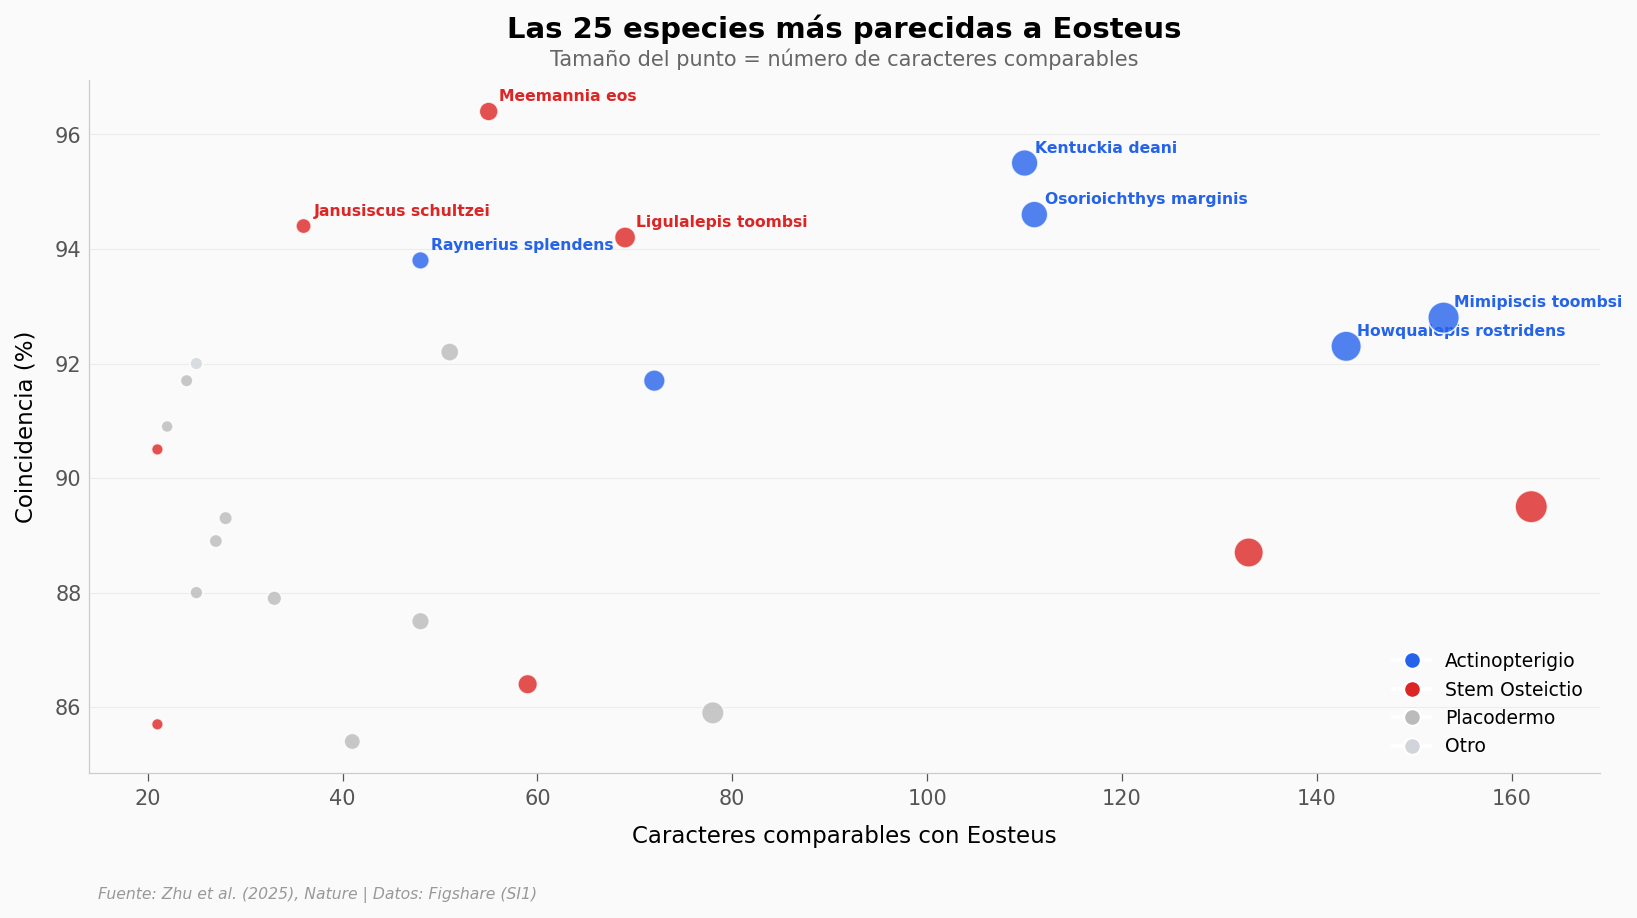

In [4]:
# Top 25 más similares con ≥20 caracteres comparables
top25 = df_sim_filt.nlargest(25, 'similitud_pct')

fig, ax = plt.subplots(figsize=(13, 6))

colors_scatter = [COLORES_GRUPO.get(g, '#D1D5DB') for g in top25['grupo']]
scatter = ax.scatter(top25['caracteres_comparables'], top25['similitud_pct'],
                     c=colors_scatter, s=top25['caracteres_comparables'] * 1.5,
                     alpha=0.8, edgecolors='white', linewidths=0.8, zorder=5)

# Etiquetar los top 8
for _, row in top25.head(8).iterrows():
    nombre = row['taxon'].replace('_', ' ')
    if len(nombre) > 25:
        nombre = nombre[:22] + '...'
    ax.annotate(nombre, xy=(row['caracteres_comparables'], row['similitud_pct']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7.5, color=COLORES_GRUPO.get(row['grupo'], '#666666'),
                fontweight='bold')

ax.set_xlabel('Caracteres comparables con Eosteus', fontsize=11)
ax.set_ylabel('Coincidencia (%)', fontsize=11)
ax.set_title('Las 25 especies más parecidas a Eosteus',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Tamaño del punto = número de caracteres comparables',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                          label=g, markersize=8)
                   for g, c in COLORES_GRUPO.items() if g in top25['grupo'].values]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/similitud_top25.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan incompleto es realmente?

Eosteus tiene el 30,5% de sus caracteres codificados. Suena poco. Pero ¿cómo se compara con el resto de la matriz?

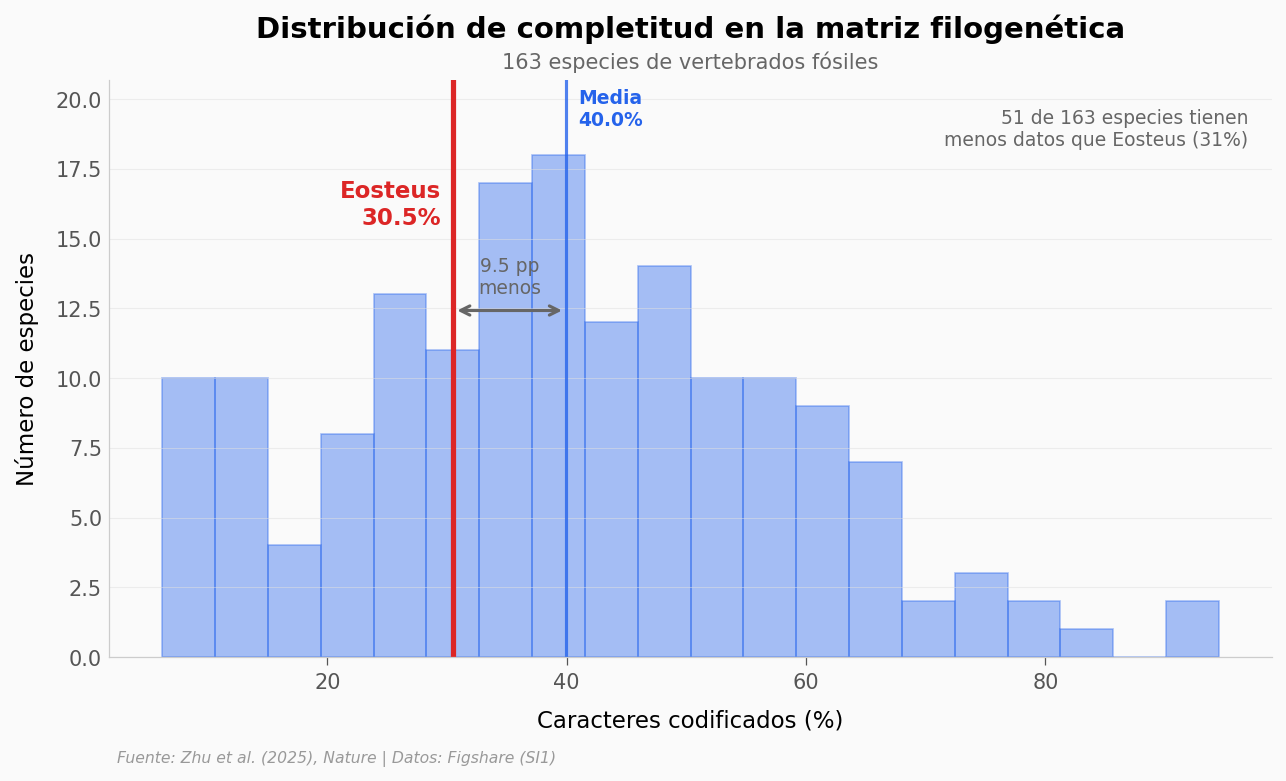

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

n_hist, bins, patches = ax.hist(df_comp['pct_complete'], bins=20,
                                 color=COLOR_DATOS, alpha=0.4,
                                 edgecolor=COLOR_DATOS, linewidth=0.8)

y_max = n_hist.max() * 1.15
ax.set_ylim(0, y_max)

# Media
media = df_comp['pct_complete'].mean()
ax.axvline(x=media, color=COLOR_DATOS, linewidth=1.5, alpha=0.8)
ax.text(media + 1, y_max * 0.92, f'Media\n{media:.1f}%', fontsize=9,
        color=COLOR_DATOS, fontweight='bold')

# Eosteus
ax.axvline(x=EOSTEUS_COMPLETITUD, color=COLOR_EOSTEUS, linewidth=2.5)
ax.text(EOSTEUS_COMPLETITUD - 1, y_max * 0.75, f'Eosteus\n{EOSTEUS_COMPLETITUD}%',
        fontsize=11, fontweight='bold', color=COLOR_EOSTEUS, ha='right')

# Flecha diferencia
ax.annotate('', xy=(media, y_max * 0.6), xytext=(EOSTEUS_COMPLETITUD, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + EOSTEUS_COMPLETITUD) / 2, y_max * 0.63,
        f'{media - EOSTEUS_COMPLETITUD:.1f} pp\nmenos', fontsize=9,
        color='#666666', ha='center')

# Percentil
n_below = (df_comp['pct_complete'] < EOSTEUS_COMPLETITUD).sum()
n_total_comp = len(df_comp)
pct_below = n_below / n_total_comp * 100
ax.text(0.98, 0.95, f'{n_below} de {n_total_comp} especies tienen\nmenos datos que Eosteus ({pct_below:.0f}%)',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='right', va='top')

ax.set_xlabel('Caracteres codificados (%)', fontsize=11)
ax.set_ylabel('Número de especies', fontsize=11)
ax.set_title('Distribución de completitud en la matriz filogenética',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{n_total_comp} especies de vertebrados fósiles',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_completitud.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Eosteus tiene rasgos típicos de actinopterigios | ✅ | Coincidencia media del 90,6% con actinopterigios, la más alta de todos los grupos (n=8 actinopterigios con ≥20 caracteres comparables) |
| La posición filogenética de Eosteus está resuelta | ⚠️ | El análisis bayesiano lo ubica en el stem osteichthyan, pero el consenso estricto lo deja sin resolver. Los datos de similitud son coherentes con ambas posibilidades |
| Los datos sugieren una radiación más extensa de peces óseos en el Silúrico | ⚠️ | El paper lo enmarca como sugerencia (*implies...than suggested*). La matriz muestra que Eosteus es distinto a otros osteíctios basales, lo que es consistente con diversidad temprana, pero no lo demuestra por sí solo |

> **Limitaciones:** (1) La coincidencia de caracteres NO es lo mismo que una filogenia — un análisis filogenético formal usa modelos de evolución de caracteres, no similitud bruta. (2) Los taxa con pocos caracteres comparables (<20) generan coincidencias artificialmente altas o bajas. (3) La matriz es una herramienta construida por los autores — la selección de caracteres y la codificación contienen decisiones subjetivas.

---

## Ahora tú

1. **¿Qué pasa si subes el filtro de caracteres comparables?** Prueba cambiando `>= 20` por `>= 50` en la celda de similitud por grupo. ¿Cambia el ranking?

2. **¿Cuál es la especie más parecida a Eosteus con >100 caracteres en común?** Busca en `df_sim_filt[df_sim_filt['caracteres_comparables'] > 100].nlargest(5, 'similitud_pct')`.

3. **¿Los placodermos son realmente un grupo homogéneo?** Con 60 especies, son el grupo más grande. ¿Cuánta variación hay en su similitud con Eosteus?

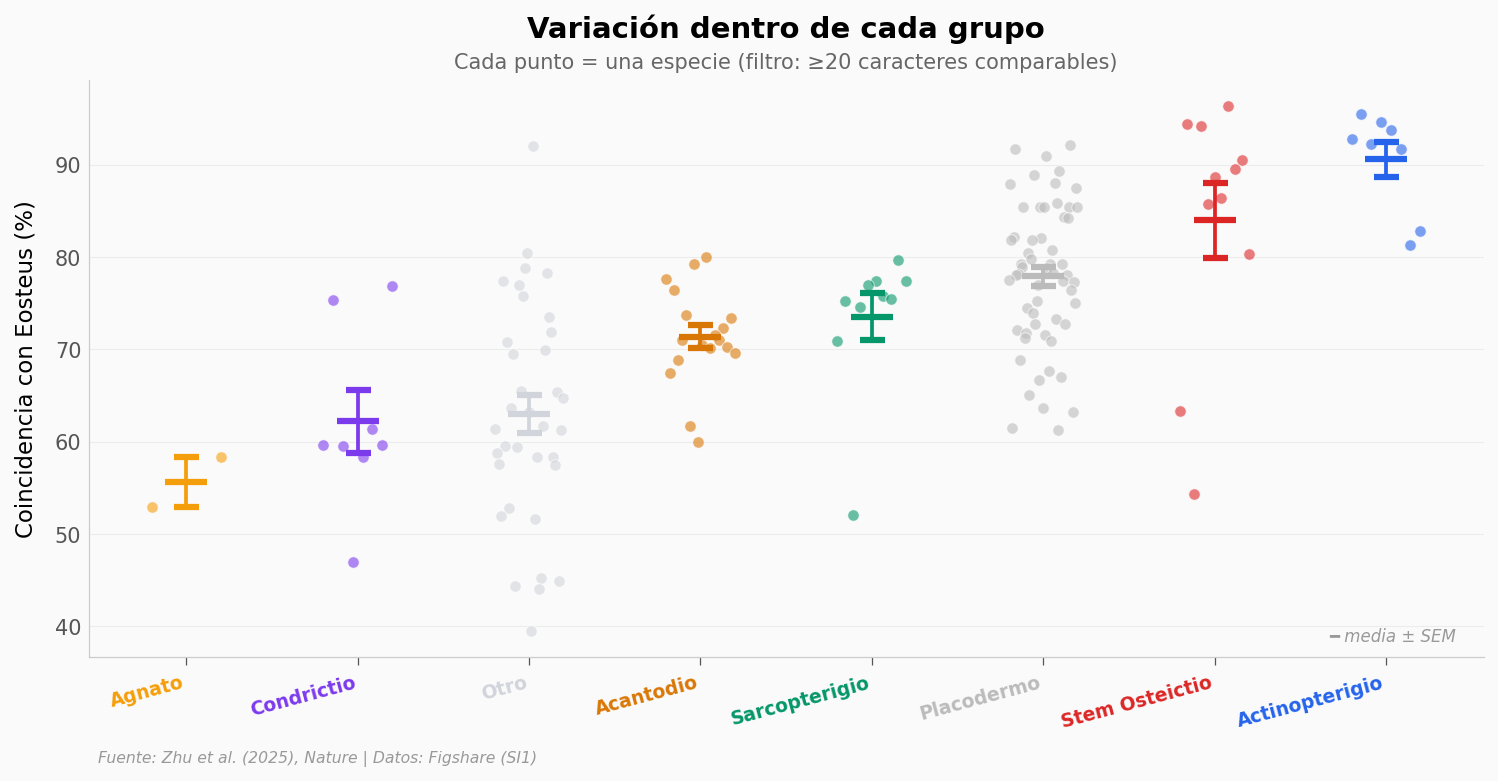

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánta variación hay DENTRO de cada grupo?
# Esto revela si un grupo es homogéneo o tiene especies muy diversas

fig, ax = plt.subplots(figsize=(12, 5))

groups_ordered = df_sim_filt.groupby('grupo')['similitud_pct'].median().sort_values().index
np.random.seed(42)

positions = list(range(len(groups_ordered)))
for i, grupo in enumerate(groups_ordered):
    vals = df_sim_filt[df_sim_filt['grupo'] == grupo]['similitud_pct'].values
    n = len(vals)
    color = COLORES_GRUPO.get(grupo, '#D1D5DB')
    
    x_strip = np.linspace(positions[i] - 0.2, positions[i] + 0.2, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=30, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    
    # Media ± SEM
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

ax.set_xticks(positions)
ax.set_xticklabels(groups_ordered, fontsize=9, fontweight='bold', rotation=15, ha='right')
for tick, grupo in zip(ax.get_xticklabels(), groups_ordered):
    tick.set_color(COLORES_GRUPO.get(grupo, '#666666'))

ax.set_ylabel('Coincidencia con Eosteus (%)', fontsize=11)
ax.set_title('Variación dentro de cada grupo',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Cada punto = una especie (filtro: ≥20 caracteres comparables)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/variacion_grupos.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Créditos

- **Paper:** Zhu et al. (2025). *Eosteus, the oldest osteichthyan.* Nature. [DOI: 10.1038/s41586-026-10125-2](https://doi.org/10.1038/s41586-026-10125-2)
- **Datos:** Supplementary Data 1 (SI1) — matriz filogenética NEXUS. Disponible en [Figshare](https://doi.org/10.6084/m9.figshare.28881827). Licencia: CC BY 4.0.
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Repo:** [GitHub](https://github.com/Ciencia-a-Mordiscos/lab)